In [1]:
import pandas as pd
import numpy as np
import os

In [19]:
from matplotlib import rcParams
import seaborn as sns

In [2]:
from constants import EQ, HH, custom_tech_colors, custom_metal_colors, custom_metal_demand

# Import data files

In [31]:
# Damage files
df_sps_damage = pd.read_excel(r'results/lca_results/corrected/df_sps_damage_regionalized.xlsx')
df_nze_damage = pd.read_excel(r'results/lca_results/corrected/df_nze_damage_regionalized.xlsx')
df_nze_damage_specific = pd.read_excel(r'results/lca_results/corrected/df_nze_damage_regionalized_specific.xlsx')
df_ssp2_damage = pd.read_excel(r'results/lca_results/corrected/df_ssp2_damage_regionalized.xlsx')
df_comparison = pd.read_csv(r'results/lca_results/comparaison_benefits_burden.csv')

In [32]:
# Quantity and demand files 
df_sps_demand = pd.read_csv(r'results/metal_demand/df_sps_metal_demand.csv')
df_nze_demand = pd.read_csv(r'results/metal_demand/df_nze_metal_demand.csv')
df_etm_roe = pd.read_csv(r'results/metal_demand/energy_transition_vs_roe_demand.csv')

## Rename columns for consistency and plotting

In [ ]:
# Group into one category for plotting
df_sps_damage["Technology"] = df_sps_damage["Technology"].replace("Other low emissions power generation", "Low emissions power generation")
df_nze_damage["Technology"] = df_nze_damage["Technology"].replace("Other low emissions power generation", "Low emissions power generation")

In [10]:
# Rename
df_sps_damage["Metal"] = df_sps_damage["Metal"].replace("Graphite (battery-grade)", "Graphite")
df_nze_damage["Metal"] = df_nze_damage["Metal"].replace("Graphite (battery-grade)", "Graphite")

## Matplotlib settings

In [15]:
### SET GLOBAL MATPLOTLIB PARAMS
rcParams['pdf.fonttype'] = 42  # to Ensure TrueType fonts are embedded
rcParams['ps.fonttype'] = 42
rcParams['font.family'] = 'arial'
rcParams['font.size'] = 10
rcParams['axes.labelsize'] = 10
rcParams['legend.fontsize'] = 9
rcParams['xtick.labelsize'] = 9
rcParams['ytick.labelsize'] = 9
rcParams['axes.titlesize'] = 12
sns.reset_orig()

# Demand vs specific LCA impacts

In [ ]:
from plotting_functions import plot_demand_vs_specific_impacts

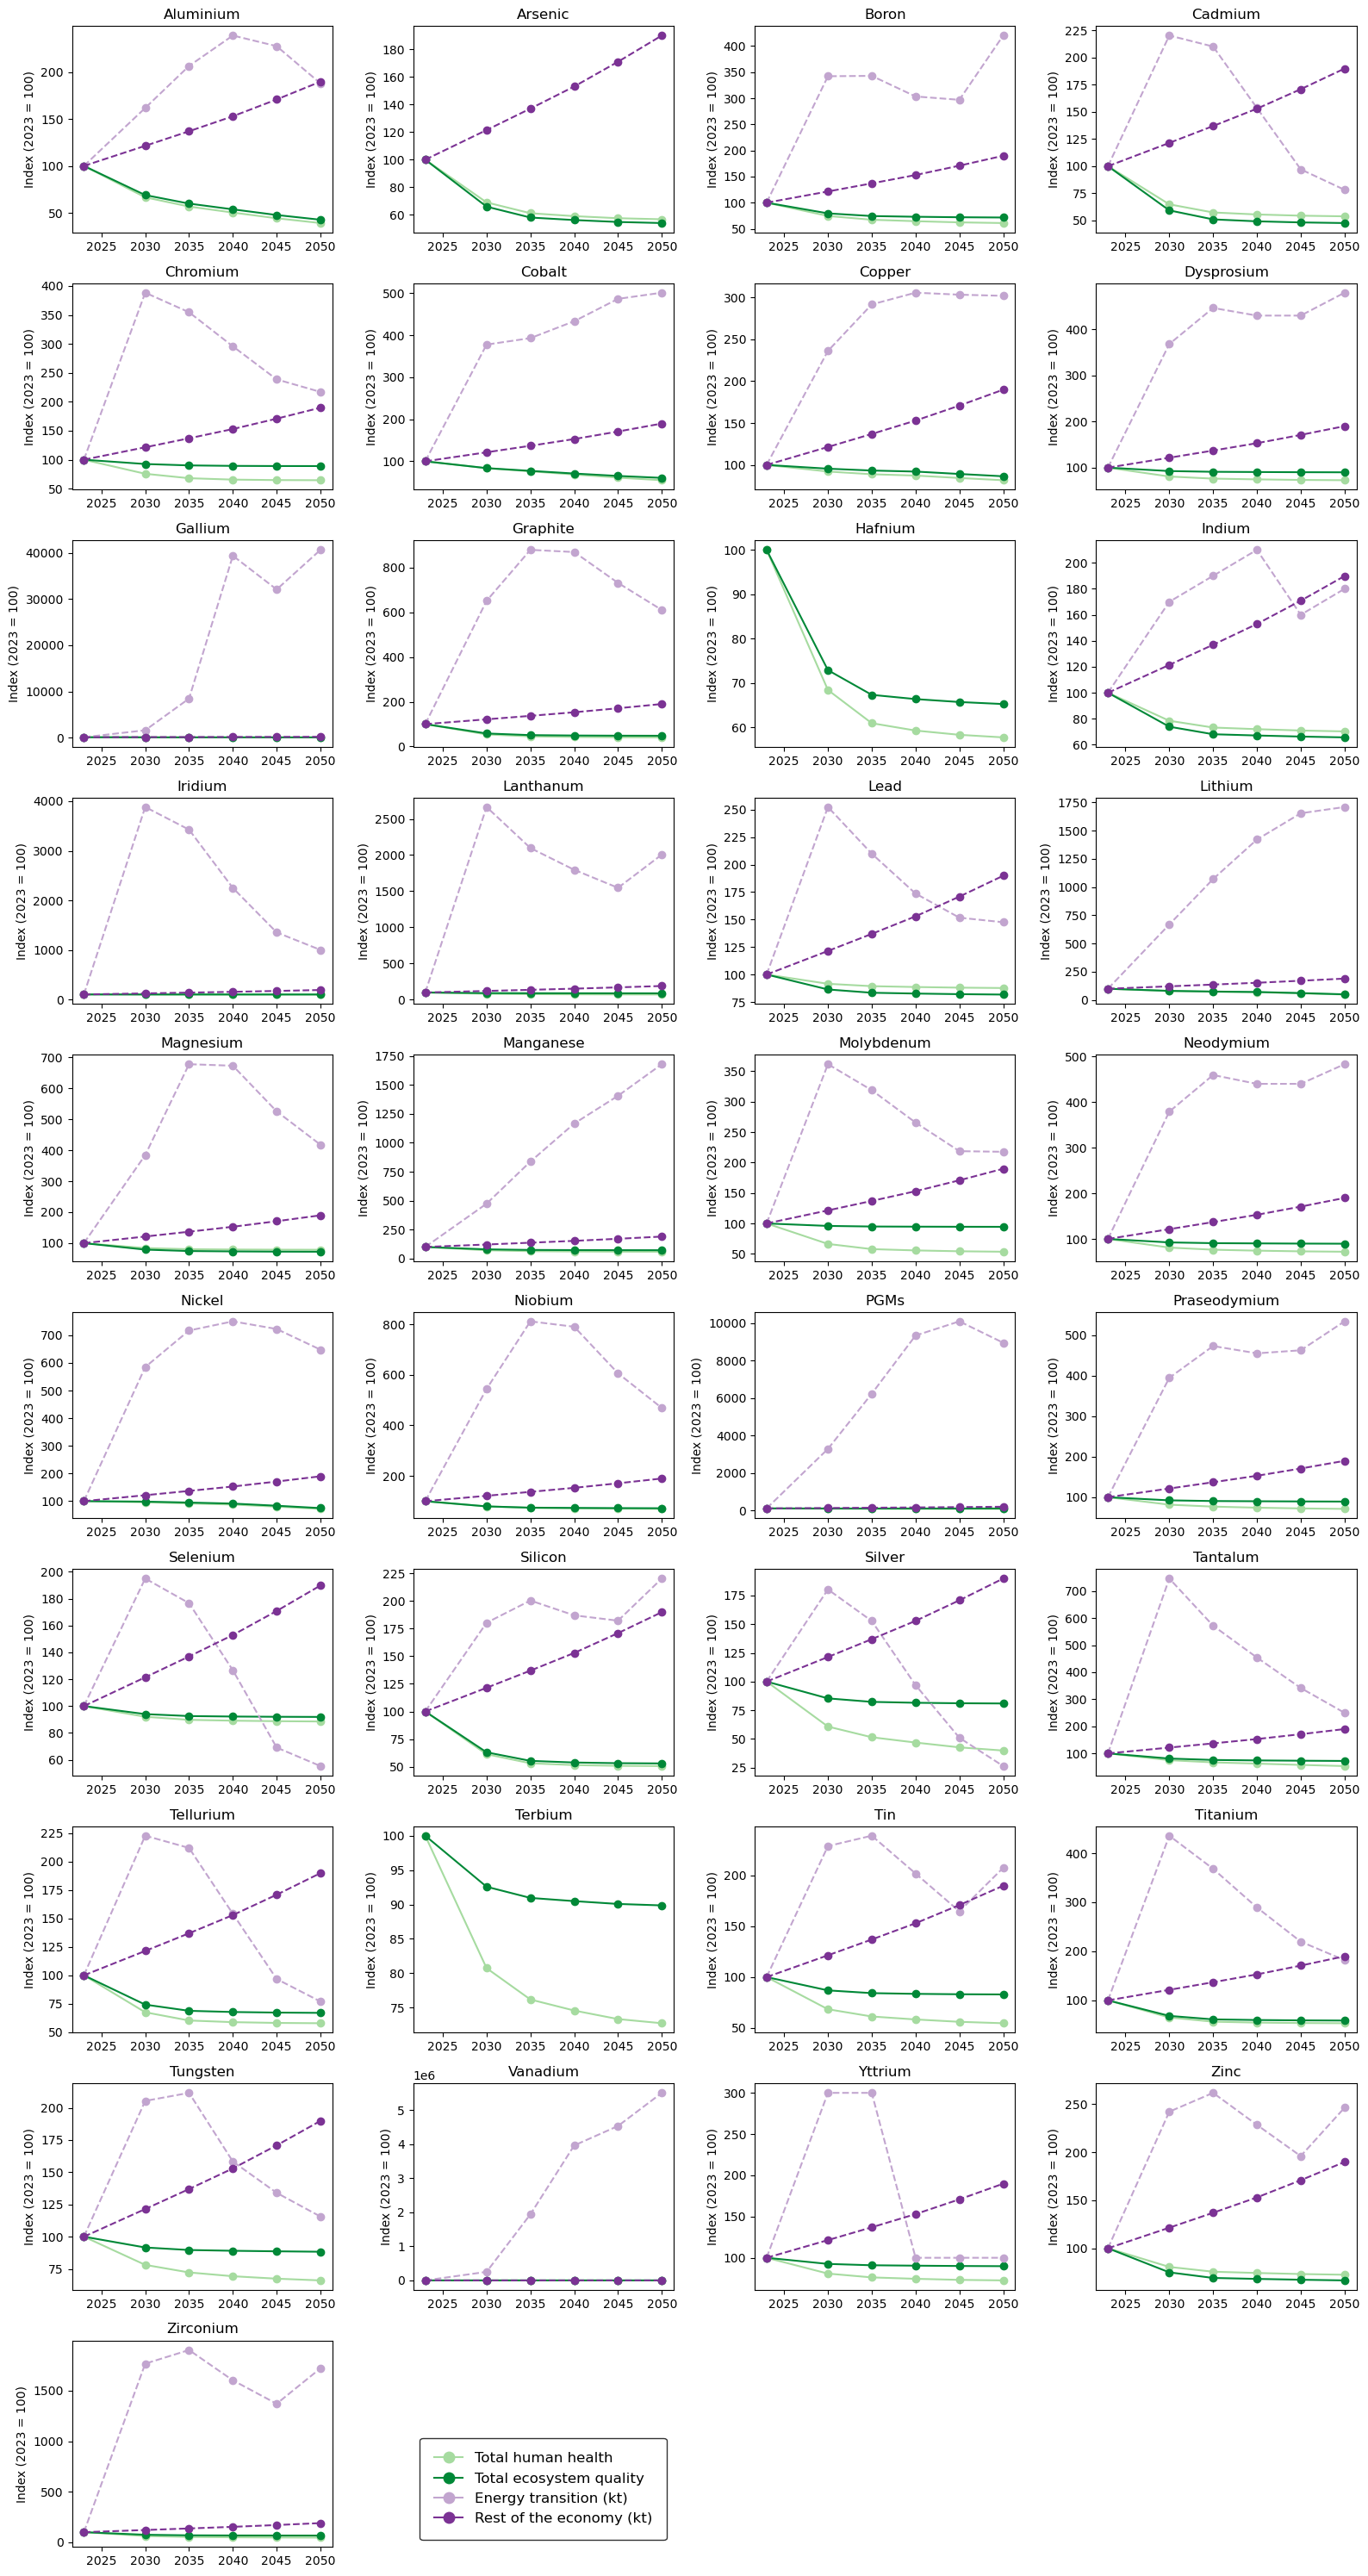

In [50]:
plot_demand_vs_specific_impacts(
    lca_df=df_nze_damage_specific,
    demand_df=df_etm_roe,
    save_path='results/plots/specific_vs_demand/specific_vs_demand_impacts',
    show=True,
    ncols=4
)

# Stacked bar from 2023 to 2050 for metals and technologies

## Metal demand

In [ ]:
from plotting_functions import plot_metal_demand_scenarios

In [13]:
custom_colors_dict = {
    "Metal": custom_metal_demand,
    "Technology": custom_tech_colors
}

In [15]:
plot_metal_demand_scenarios(df_nze_demand, df_sps_demand, "results/plots/metal_demand/metal_demand_scenarios", custom_colors_dict)

## LCA impacts

In [15]:
from plotting_functions import plot_metal_lca_impacts

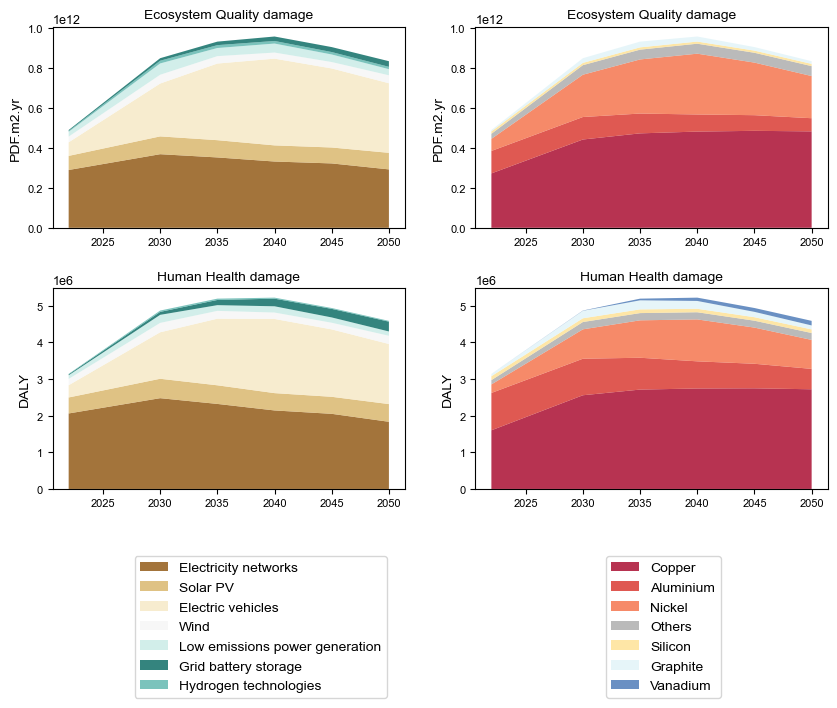

In [16]:
stacked_area_sps = plot_metal_lca_impacts(
    df=df_sps_damage,
    value_cols=["Total ecosystem quality", "Total human health"],
    group_by_options=["Technology", "Metal"],
    titles=[
        ["Ecosystem Quality damage", "Ecosystem Quality damage"],
        ["Human Health damage", "Human Health damage"]
    ],
    y_labels=["PDF.m2.yr", "DALY"],
    custom_colors_dict={
        "Technology": custom_tech_colors,
        "Metal": custom_metal_colors
    },
    save_path="results/plots/stacked_area_metals_technologies/combined_stacked_area_sps"
)


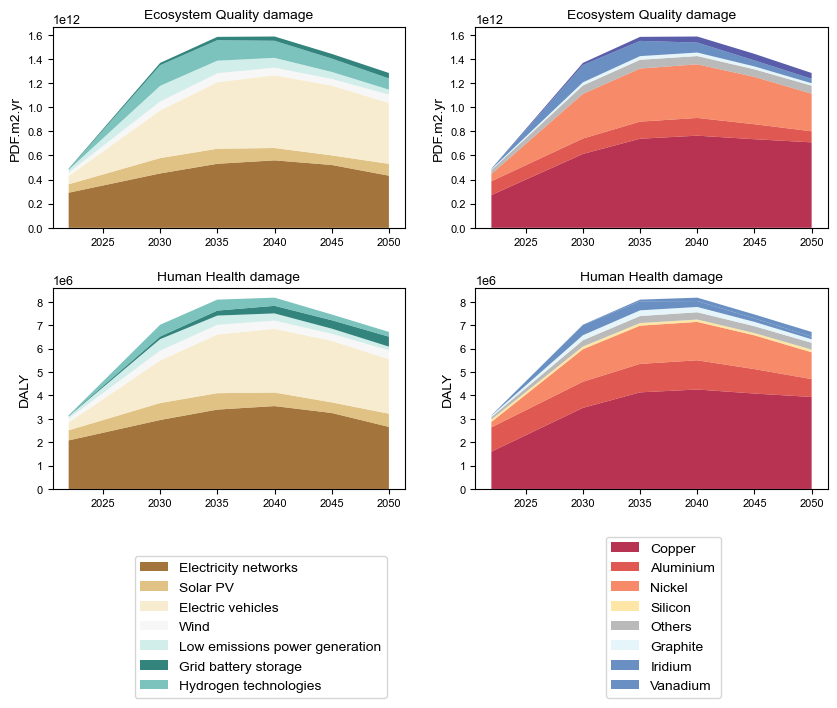

In [17]:
stacked_area_nze = plot_metal_lca_impacts(
    df=df_nze_damage,
    value_cols=["Total ecosystem quality", "Total human health"],
    group_by_options=["Technology", "Metal"],
    titles=[
        ["Ecosystem Quality damage", "Ecosystem Quality damage"],
        ["Human Health damage", "Human Health damage"]
    ],
    y_labels=["PDF.m2.yr", "DALY"],
    custom_colors_dict={
        "Technology": custom_tech_colors,
        "Metal": custom_metal_colors
    },
    save_path="results/plots/stacked_area_metals_technologies/combined_stacked_area_nze"
)

# Midpoint contribution analysis

In [ ]:
from constants import agg_mapping_hh, agg_mapping_eq

## Per year

In [ ]:
from plotting_functions import plot_midpoint_contribution

In [90]:
# Define the directory for saving bar plots
barplot_dir = "results/plots/midpoint_contribution"
os.makedirs(barplot_dir, exist_ok=True)

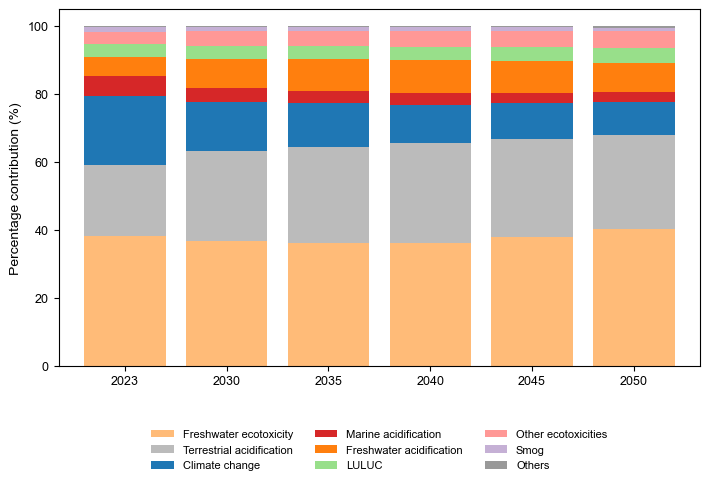

In [91]:
fig_sps_mp_eq = plot_midpoint_contribution(df_sps_damage, 
                                           impact_columns= list(agg_mapping_eq.keys()),
                                           total_col="Total ecosystem quality",
                                           title="Midpoint Contributions to Ecosystem Quality",
                                           mapping_dict=agg_mapping_eq,
                                           save_path=f"{barplot_dir}/fig_sps_mp_eq")

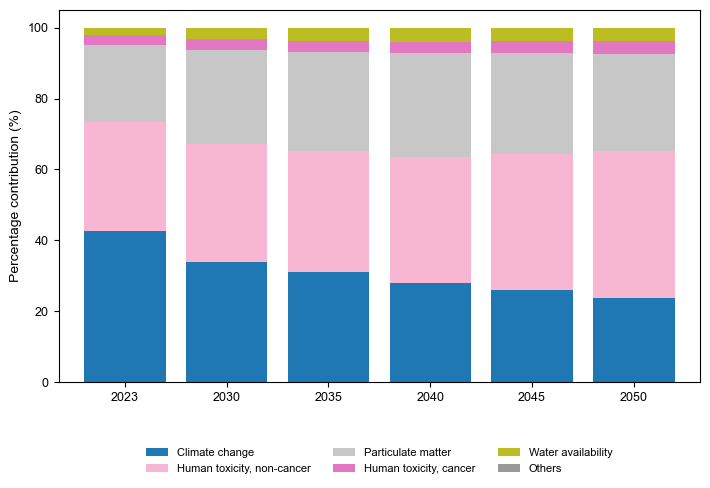

In [92]:
fig_sps_mp_hh = plot_midpoint_contribution(df_sps_damage, 
                                           impact_columns= list(agg_mapping_hh.keys()),
                                           total_col="Total human health",
                                           title="Midpoint Contributions to Human Health",
                                           mapping_dict=agg_mapping_hh,
                                           save_path=f"{barplot_dir}/fig_sps_mp_hh")

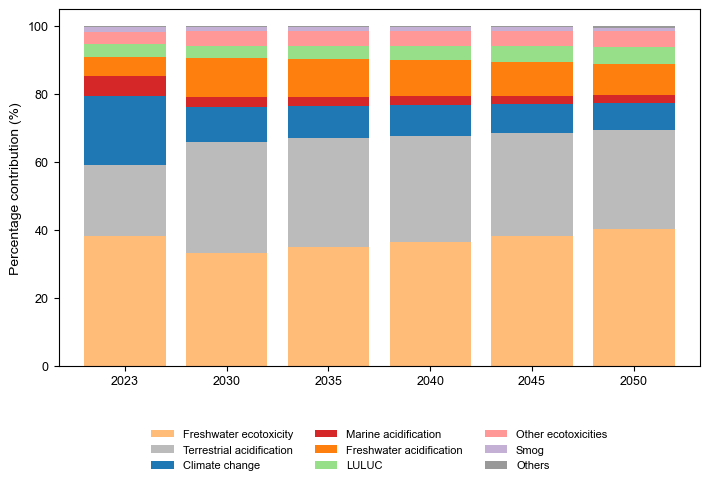

In [93]:
fig_nze_mp_eq = plot_midpoint_contribution(df_nze_damage, 
                                           impact_columns= list(agg_mapping_eq.keys()),
                                           total_col="Total ecosystem quality",
                                           title="Midpoint Contributions to Ecosystem Quality",
                                           mapping_dict=agg_mapping_eq,
                                           save_path=f"{barplot_dir}/fig_nze_mp_eq")

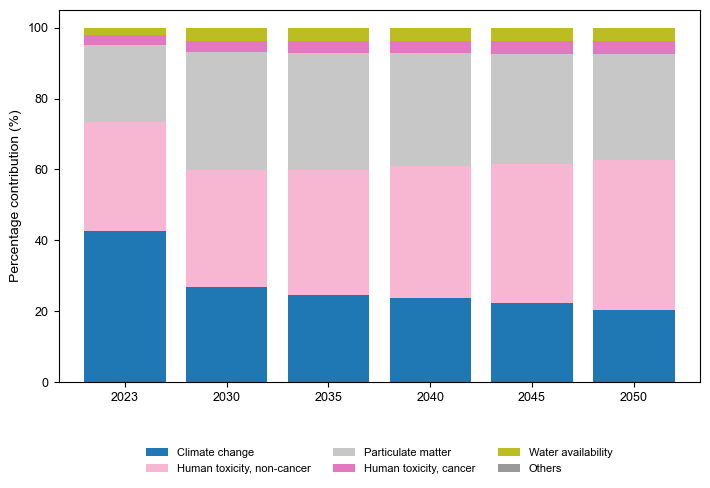

In [94]:
fig_nze_mp_hh = plot_midpoint_contribution(df_nze_damage, 
                                           impact_columns= list(agg_mapping_hh.keys()),
                                           total_col="Total human health",
                                           title="Midpoint Contributions to Human Health",
                                           mapping_dict=agg_mapping_hh,
                                           save_path=f"{barplot_dir}/fig_nze_mp_hh")

## Cumulative

In [34]:
from plotting_functions import plot_cumulative_midpoint_contribution

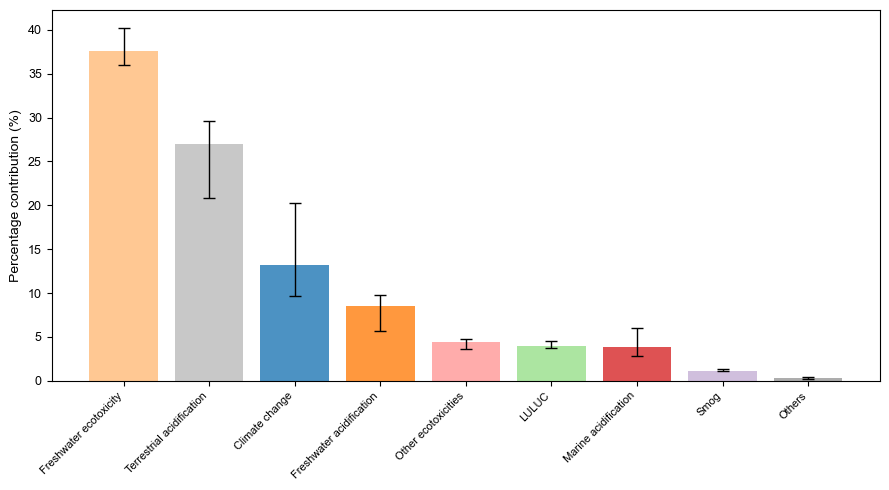

In [98]:
fig_sps_mp_eq_cum = plot_cumulative_midpoint_contribution(df_sps_damage, 
                                                          impact_columns= list(agg_mapping_eq.keys()), 
                                                          total_col="Total ecosystem quality",
                                                          title="Cumulative Midpoint Contributions (2022-2050) - Ecosystem Quality",
                                                          mapping_dict=agg_mapping_eq,
                                                          save_path="results/plots/midpoint_contribution/fig_sps_mp_eq_cum")

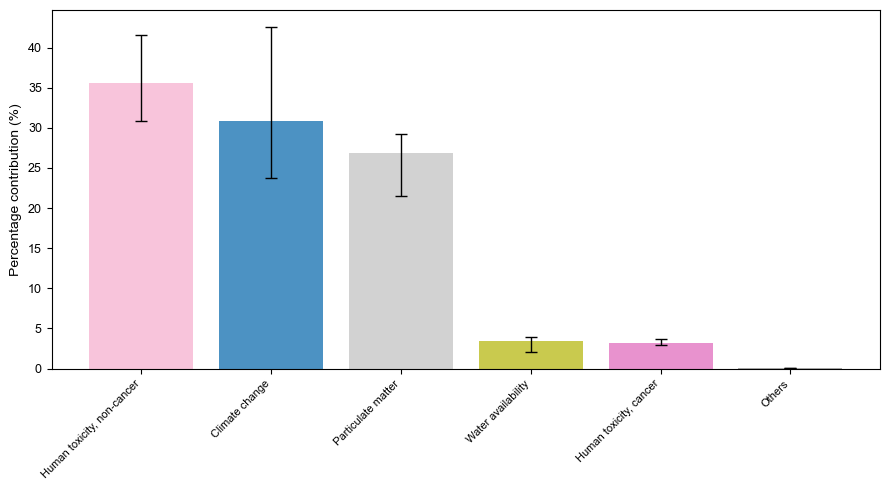

In [99]:
fig_sps_mp_hh_cum = plot_cumulative_midpoint_contribution(df_sps_damage, 
                                                          impact_columns= list(agg_mapping_hh.keys()), 
                                                          total_col="Total human health",
                                                          title="Cumulative Midpoint Contributions (2022-2050) - Human Health",
                                                          mapping_dict=agg_mapping_hh,
                                                          save_path="results/plots/midpoint_contribution/fig_sps_mp_hh_cum")

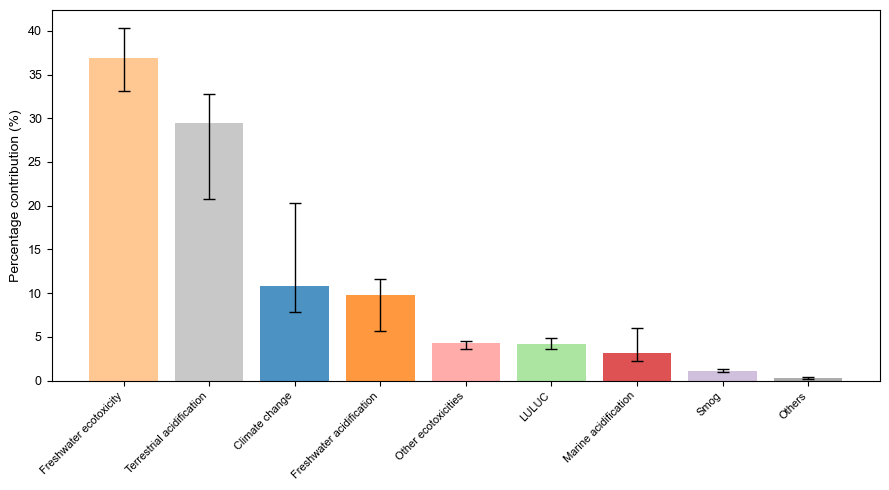

In [100]:
fig_nze_mp_eq_cum = plot_cumulative_midpoint_contribution(df_nze_damage, 
                                                          impact_columns= list(agg_mapping_eq.keys()), 
                                                          total_col="Total ecosystem quality",
                                                          title="Cumulative Midpoint Contributions (2022-2050) - Ecosystem Quality",
                                                          mapping_dict=agg_mapping_eq,
                                                          save_path="results/plots/midpoint_contribution/fig_nze_mp_eq_cum")


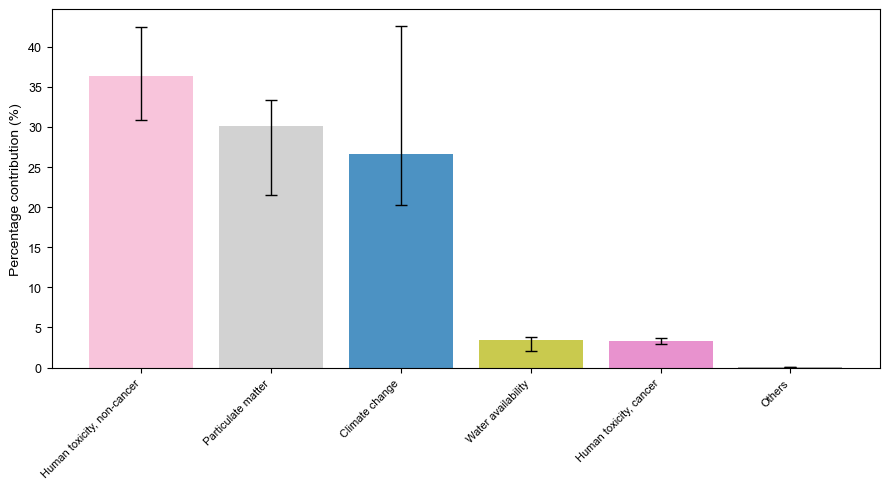

In [101]:
fig_nze_mp_hh_cum = plot_cumulative_midpoint_contribution(df_nze_damage, 
                                                          impact_columns= list(agg_mapping_hh.keys()), 
                                                          total_col="Total human health",
                                                          title="Cumulative Midpoint Contributions (2022-2050) - Human Health",
                                                          mapping_dict=agg_mapping_hh,
                                                          save_path="results/plots/midpoint_contribution/fig_nze_mp_hh_cum")

# Sankey

In [107]:
from plotting_functions import create_sankey

In [108]:
from constants import agg_mapping_eq, agg_mapping_hh, metal_map

In [109]:
# Define directory for saving Sankey diagrams
sankey_dir = "results/plots/sankey"
os.makedirs(sankey_dir, exist_ok=True)

In [61]:
fig_sps_eq = create_sankey(
    df_sps_damage,
    total_col="Total ecosystem quality",
    impact_columns=EQ,
    #title="",
    save_path=f"{sankey_dir}/sps_eq",
    agg_mapping=agg_mapping_eq,
    metal_mapping=metal_map
)

fig_sps_hh = create_sankey(
    df_sps_damage,
    total_col="Total human health",
    impact_columns=HH,
    #title="",
    save_path=f"{sankey_dir}/sps_hh",
    agg_mapping=agg_mapping_hh,
    metal_mapping=metal_map
)


C:\Users\mp_ma\AppData\Local\Temp\ipykernel_21052\4140479495.py:36: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.

C:\Users\mp_ma\AppData\Local\Temp\ipykernel_21052\4140479495.py:36: DeprecationWarning:

DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.



In [110]:
fig_nze_eq = create_sankey(
    df_nze_damage,
    total_col="Total ecosystem quality",
    impact_columns=EQ,
    #title="",
    save_path=f"{sankey_dir}/nze_eq",
    agg_mapping=agg_mapping_eq,
    metal_mapping=metal_map
)

fig_nze_hh = create_sankey(
    df_nze_damage,
    total_col="Total human health",
    impact_columns=HH,
    #title="",
    save_path=f"{sankey_dir}/nze_hh",
    agg_mapping=agg_mapping_hh,
    metal_mapping=metal_map
)

# Benefits vs burden of the transition

In [111]:
from plotting_functions import plot_lineplot_logscale

In [112]:
plot_lineplot_logscale(df_comparison, save_path='results/plots/burden_comparison/lineplot_logscale')

# Energy transition vs rest of the economy

## Subplots

### Quantities

In [183]:
from plotting_functions import plot_all_metals_subplots

In [184]:
plot_all_metals_subplots(
    df_etm_roe,
    ncols=4,
    save_path='results/plots/et_vs_roe/qty_subplots')

### Impacts

In [116]:
from plotting_functions import plot_all_metals_subplots_damage

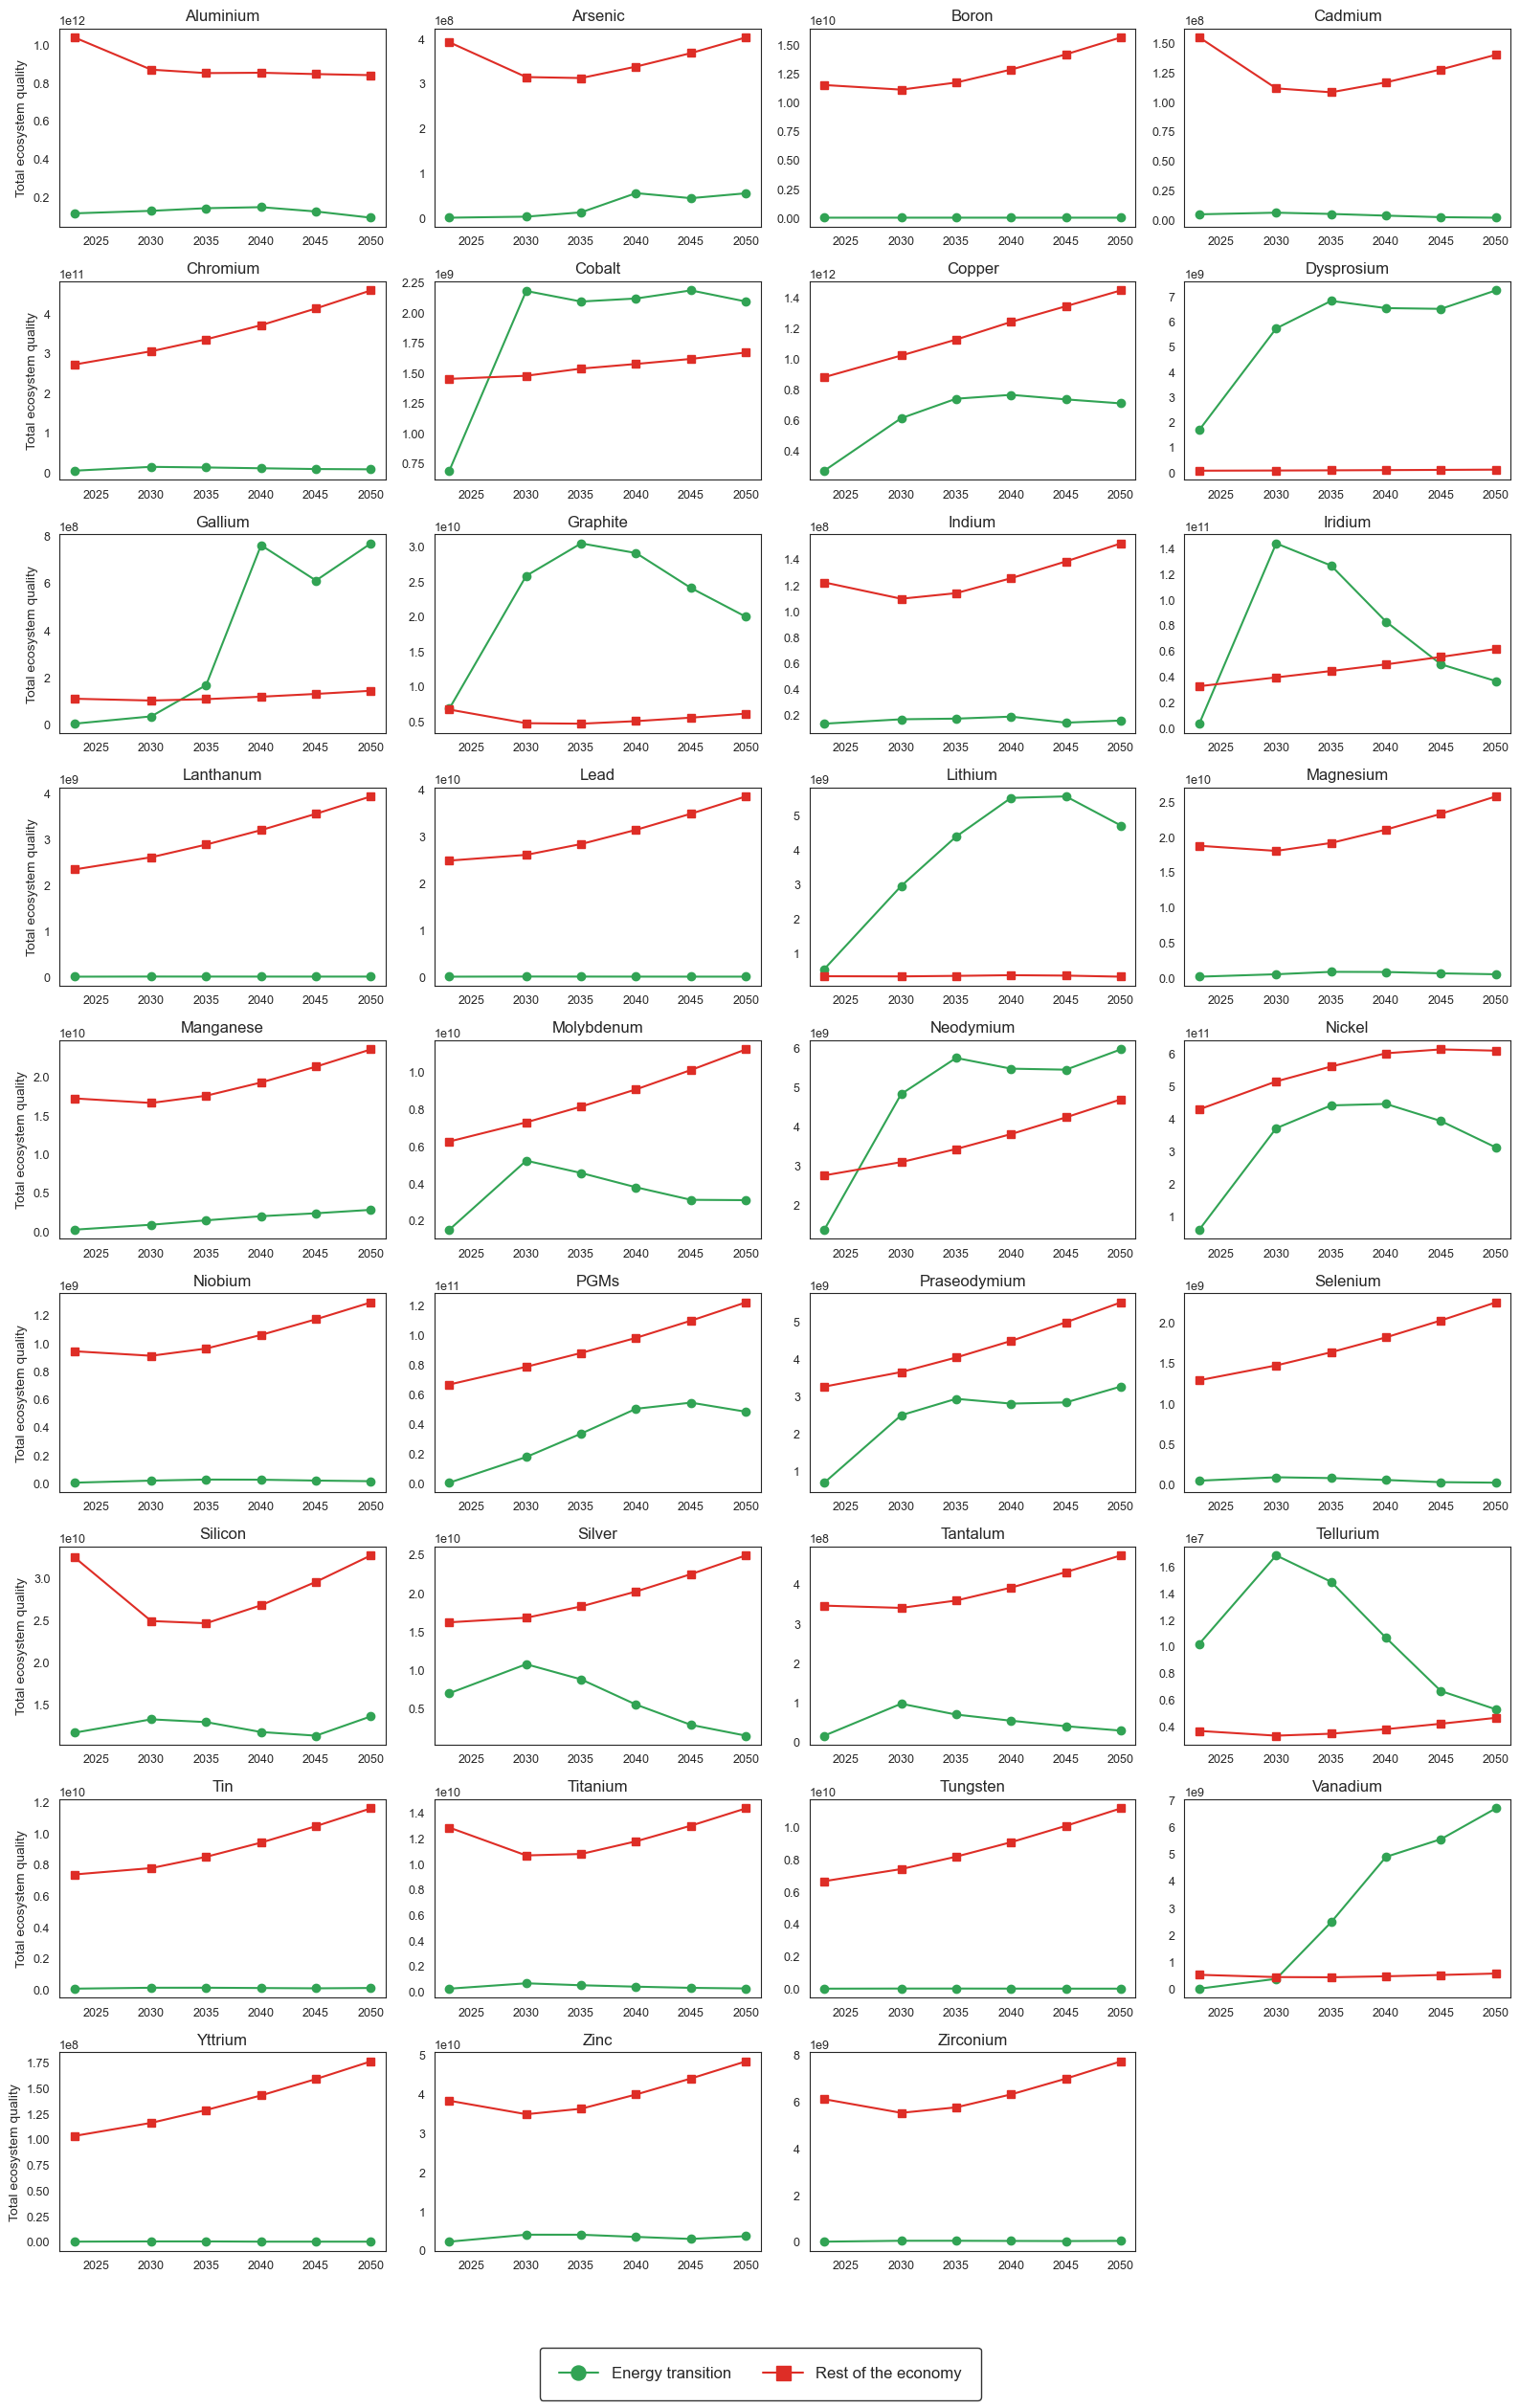

In [117]:
# Re-plot with NZE values aggregated by metal
plot_all_metals_subplots_damage(df_nze_damage, df_ssp2_damage,
                                           impact_type="Total ecosystem quality",
                                           save_path='results/plots/et_vs_roe/eq_subplots',
                                           ncols=4)

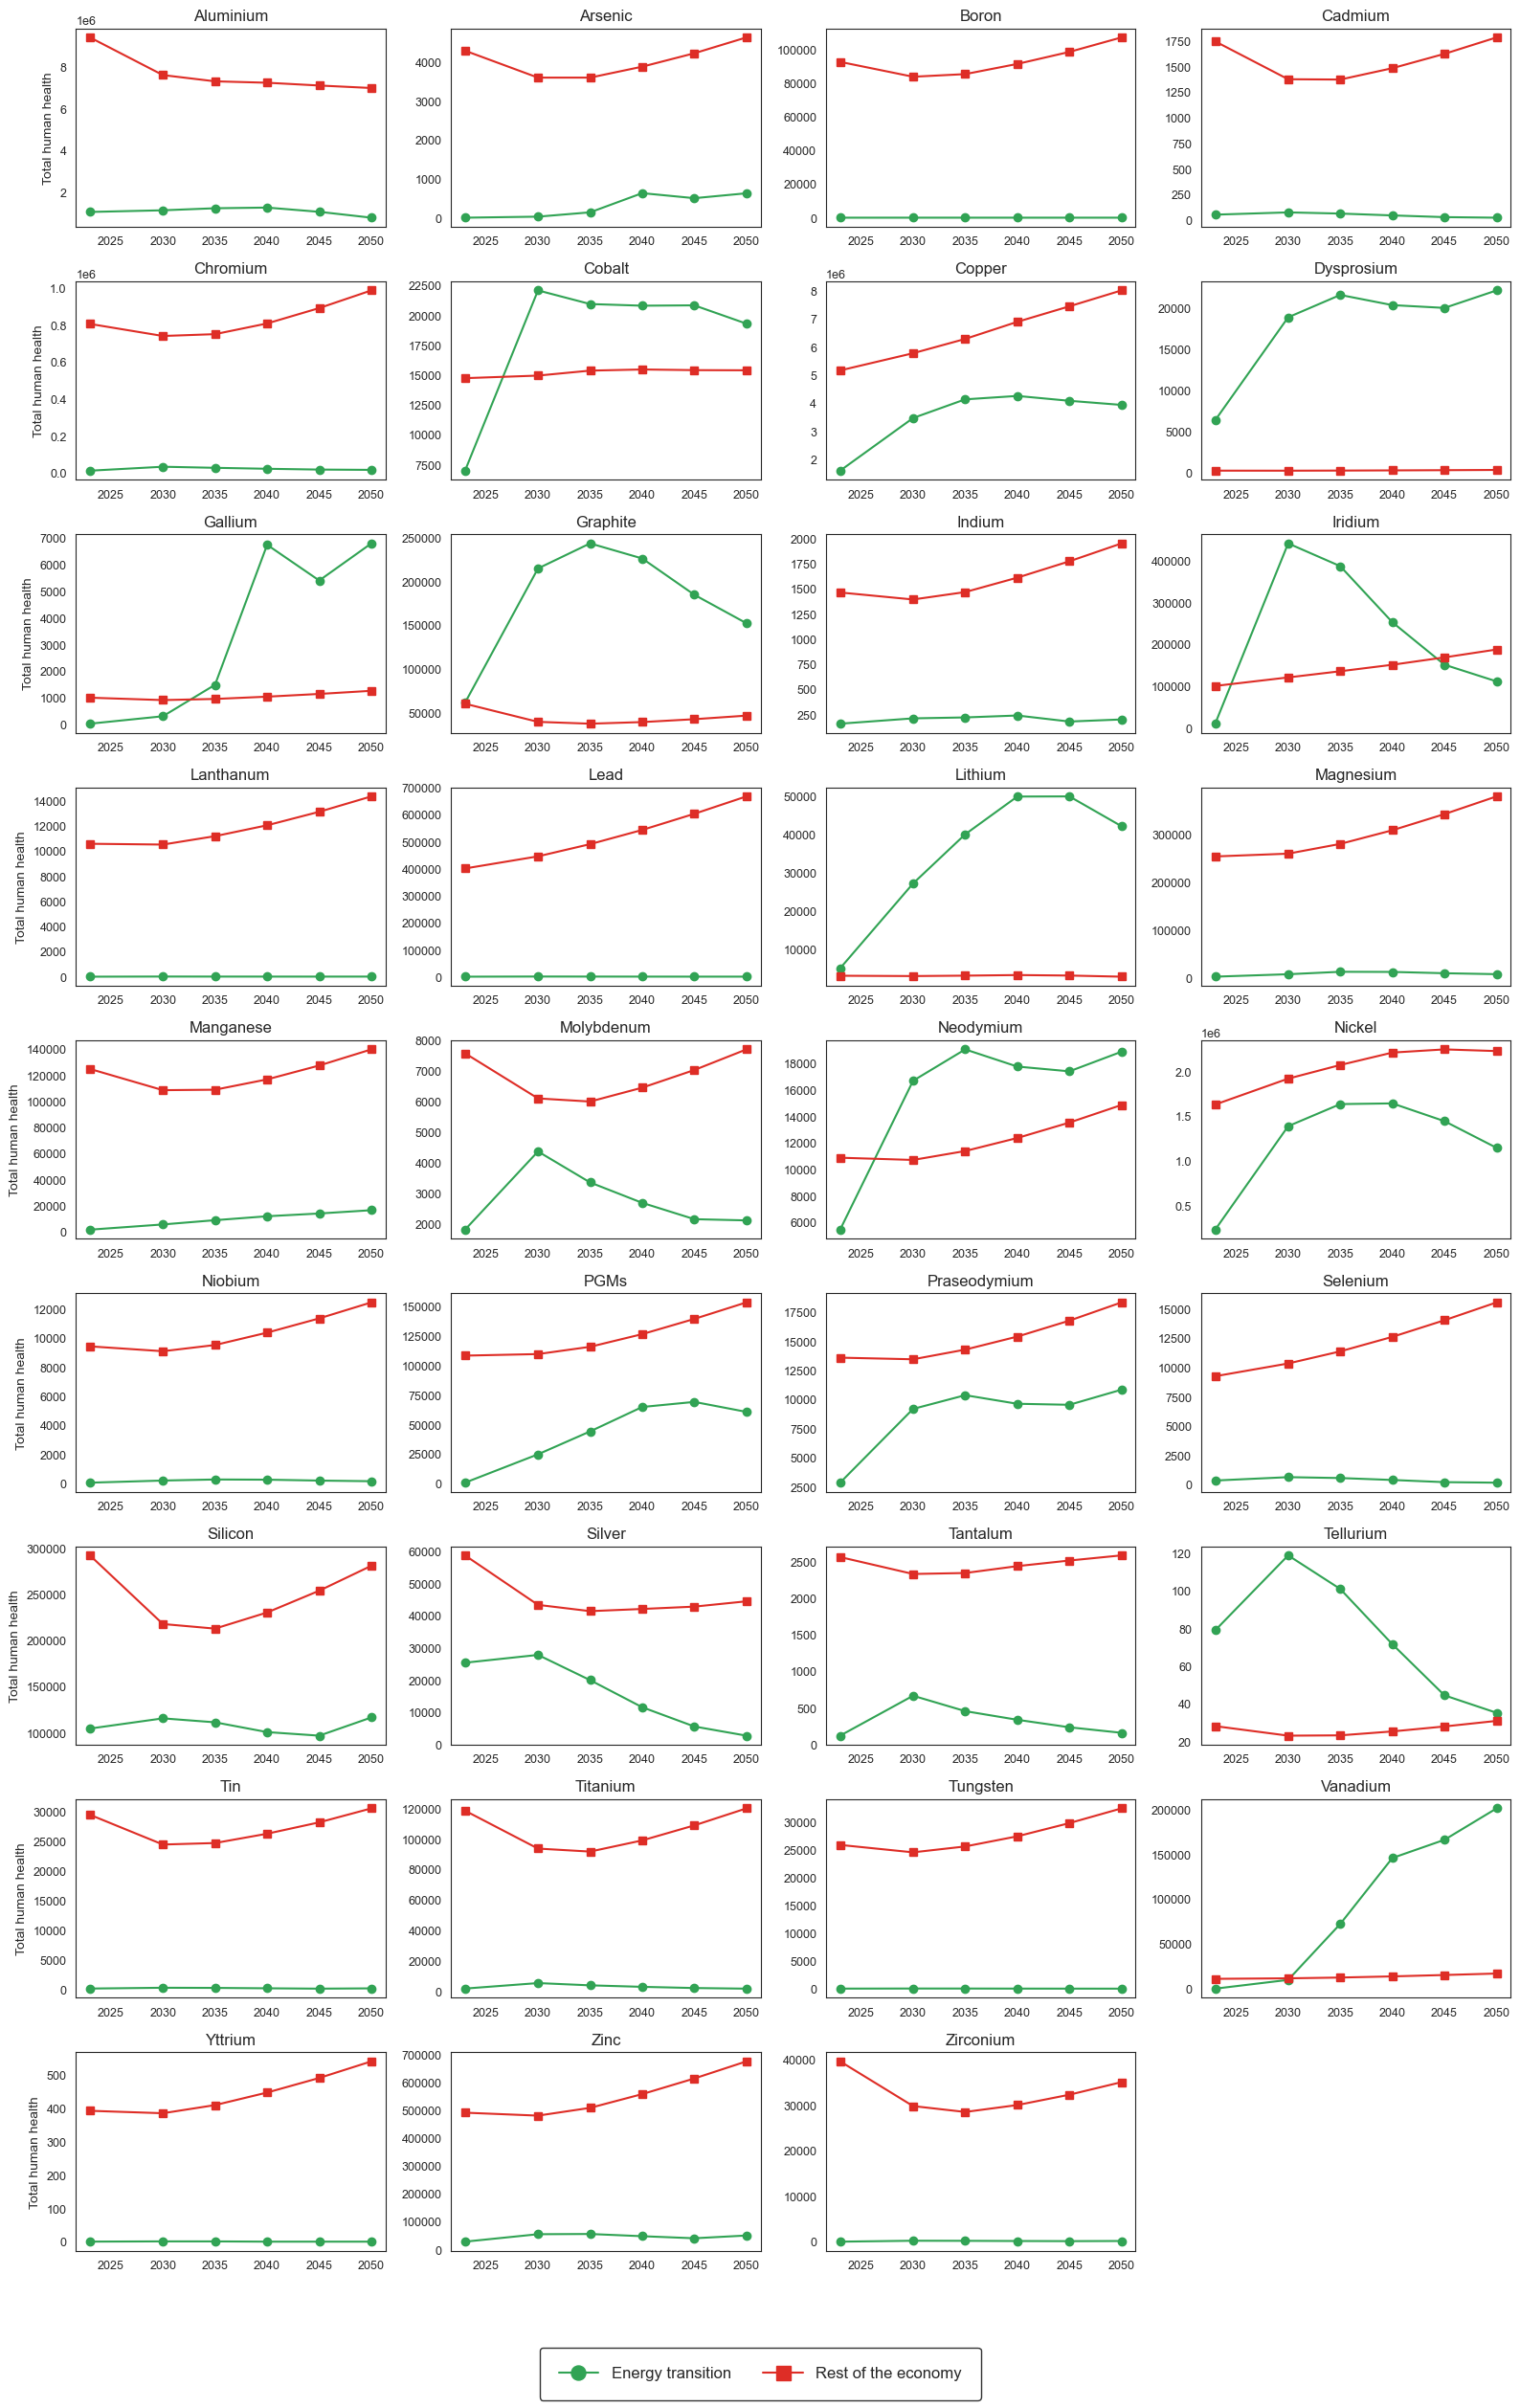

In [118]:
# Re-plot with NZE values aggregated by metal
plot_all_metals_subplots_damage(df_nze_damage, df_ssp2_damage,
                                           impact_type="Total human health",
                                    save_path='results/plots/et_vs_roe/hh_subplots',
                                           ncols=4)

## Stacked area plot

In [189]:
df_nze_damage_int = pd.read_excel(r'results/corrected/df_nze_damage_regionalized_detailed.xlsx', sheet_name='yearly')
df_ssp2_damage_int = pd.read_excel(r'results/corrected/df_ssp2_damage_regionalized_detailed.xlsx', sheet_name='yearly')

In [198]:
# Group by year and sum the relevant impact categories
nze_grouped = df_nze_damage_int.groupby("Year")[["Total ecosystem quality", "Total human health"]].sum()
ssp2_grouped = df_ssp2_damage_int.groupby("Year")[["Total ecosystem quality", "Total human health"]].sum()

# Combine the data
combined = pd.DataFrame()
combined["Total EQ - NZE (%)"] = nze_grouped["Total ecosystem quality"] / (
    nze_grouped["Total ecosystem quality"] + ssp2_grouped["Total ecosystem quality"]
) * 100
combined["Total HH - NZE (%)"] = nze_grouped["Total human health"] / (
    nze_grouped["Total human health"] + ssp2_grouped["Total human health"]
) * 100
combined.index.name = "Year"
combined

,Total EQ - NZE (%),Total HH - NZE (%)
Year,,
2023,14.311606,14.011300
2024,17.269701,16.189770
2025,20.005602,18.293664
2026,22.543437,20.326746
2027,24.903965,22.292532
2028,27.105139,24.194310
2029,29.162568,26.035156
2030,31.089889,27.817951
2031,31.494886,28.319502


In [196]:
df_ssp2_damage_int

,Year,Scenario,Metal,Technology,"Climate change, ecosystem quality, long term","Climate change, ecosystem quality, short term","Climate change, human health, long term","Climate change, human health, short term",Fisheries impact,Freshwater acidification,...,"Photochemical ozone formation, human health",Terrestrial acidification,"Terrestrial ecotoxicity, long term","Terrestrial ecotoxicity, short term",Thermally polluted water,"Water availability, freshwater ecosystem","Water availability, human health","Water availability, terrestrial ecosystem",Total human health,Total ecosystem quality
0,2023,NZE,Aluminium,Rest of the economy,4.378327e+11,1.302564e+11,5.900660e+06,1.755461e+06,0.045556,9.961850e+09,...,1736.247282,7.848170e+10,2.290726e+09,1.940932e+09,2.925511e+08,1.702519e+06,37148.281948,4.208396e+07,9.416014e+06,1.038220e+12
1,2024,NZE,Aluminium,Rest of the economy,4.249843e+11,1.262421e+11,5.727502e+06,1.701362e+06,0.055925,9.975175e+09,...,1704.721322,7.795723e+10,2.337182e+09,1.989697e+09,2.959268e+08,1.687349e+06,37536.442030,4.040117e+07,9.157746e+06,1.014033e+12
2,2025,NZE,Aluminium,Rest of the economy,4.121359e+11,1.222279e+11,5.554344e+06,1.647262e+06,0.066294,9.988501e+09,...,1673.195363,7.743276e+10,2.383639e+09,2.038463e+09,2.993025e+08,1.672178e+06,37924.602112,3.871838e+07,8.899479e+06,9.898462e+11
3,2026,NZE,Aluminium,Rest of the economy,3.992875e+11,1.182136e+11,5.381186e+06,1.593162e+06,0.076663,1.000183e+10,...,1641.669404,7.690829e+10,2.430095e+09,2.087228e+09,3.026783e+08,1.657007e+06,38312.762195,3.703560e+07,8.641211e+06,9.656595e+11
4,2027,NZE,Aluminium,Rest of the economy,3.864391e+11,1.141994e+11,5.208029e+06,1.539062e+06,0.087032,1.001515e+10,...,1610.143444,7.638383e+10,2.476552e+09,2.135994e+09,3.060540e+08,1.641836e+06,38700.922277,3.535281e+07,8.382944e+06,9.414728e+11
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
975,2046,NZE,Zirconium,Rest of the economy,9.666360e+08,2.899685e+08,1.302733e+04,3.907898e+03,0.007029,5.543098e+07,...,12.636518,2.787508e+08,3.949890e+07,7.028056e+07,1.439467e+06,6.826287e+04,4641.793111,6.581241e+06,3.285134e+04,7.115275e+09
976,2047,NZE,Zirconium,Rest of the economy,9.772621e+08,2.931473e+08,1.317053e+04,3.950739e+03,0.007033,5.671458e+07,...,12.910018,2.850237e+08,4.038831e+07,7.207314e+07,1.468598e+06,6.968409e+04,4748.624107,6.726962e+06,3.340378e+04,7.262696e+09
977,2048,NZE,Zirconium,Rest of the economy,9.878881e+08,2.963262e+08,1.331374e+04,3.993580e+03,0.007037,5.799818e+07,...,13.183518,2.912966e+08,4.127772e+07,7.386573e+07,1.497729e+06,7.110531e+04,4855.455103,6.872682e+06,3.395621e+04,7.410116e+09
978,2049,NZE,Zirconium,Rest of the economy,9.985142e+08,2.995050e+08,1.345695e+04,4.036421e+03,0.007041,5.928179e+07,...,13.457018,2.975695e+08,4.216713e+07,7.565832e+07,1.526860e+06,7.252652e+04,4962.286099,7.018403e+06,3.450864e+04,7.557537e+09


In [192]:
nze_totals = df_nze_damage_int[["Total ecosystem quality", "Total human health"]].sum()
nze_totals

Total ecosystem quality    3.708971e+13
Total human health         1.935432e+08
dtype: float64

In [193]:
ssp2_totals = df_ssp2_damage_int[["Total ecosystem quality", "Total human health"]].sum()
ssp2_totals

Total ecosystem quality    9.295102e+13
Total human health         5.442491e+08
dtype: float64

In [195]:
percentage_contributions = (nze_totals / (nze_totals + ssp2_totals)) * 100
percentage_contributions

Total ecosystem quality    28.521609
Total human health         26.232744
dtype: float64

In [124]:
from plotting_functions import plot_stacked_overlay_subplot
from constants import custom_metal_roe_colors

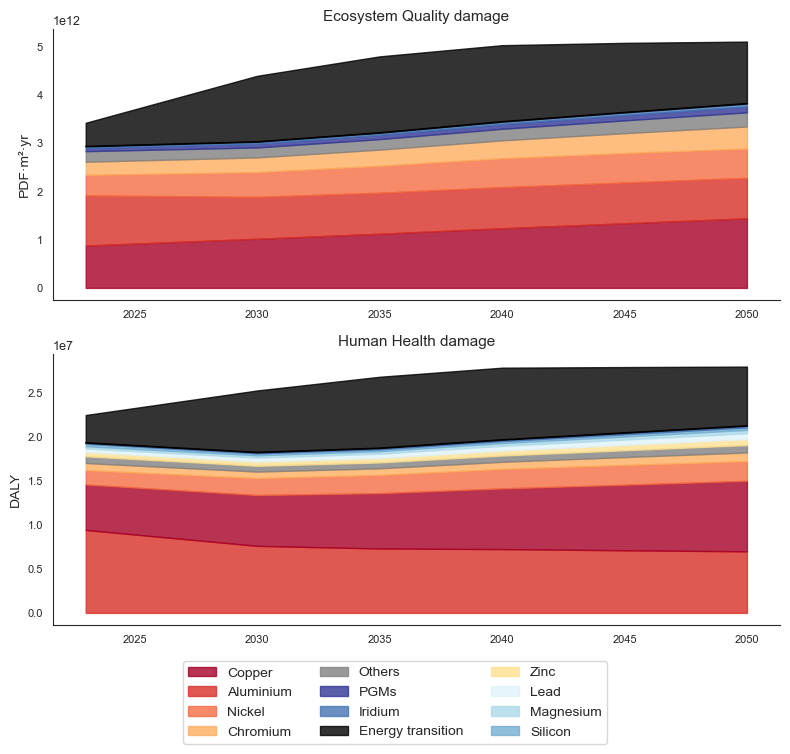

In [125]:
plot_stacked_overlay_subplot(
    df_nze=df_nze_damage,
    df_ssp2=df_ssp2_damage,
    group_by="Metal",
    value_cols=["Total ecosystem quality", "Total human health"],
    titles=["Ecosystem Quality damage", "Human Health damage"],
    y_labels=["PDF·m²·yr", "DALY"],
    custom_colors=custom_metal_roe_colors,
    save_path="results/plots/et_vs_roe/combined_overlay.pdf"
)
